# Surrogate Checkpoint Evaluation

For each `.pt` surrogate checkpoint in `checkpoints/`, computes the relative L2 error on the **physical** field U(t) and displays histograms/comparison plots.

Supports all surrogate types: `SLAEModel`, `LLAEModel`, `SLAESVDModel`, `LLAESVDModel`, `CorrectionAE`.

In [14]:
import sys, os
os.environ.setdefault('PYTORCH_CUDA_ALLOC_CONF', 'expandable_segments:True')
sys.path.insert(0, os.path.join('..', 'src'))

import glob
import re
import gc
import numpy as np
import torch
import torch.nn.functional as F_nn
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from laplace_surrogate.inference.pipeline import InferencePipeline

## 1. Dataset loading

In [15]:
DATA_PATH  = '../dataset/ch4_rotated.npy'
DOE_PATH   = '../dataset/doe_rotated.npy'
SPLIT_PATH = '../dataset/split.npz'
CKPT_DIR   = '../checkpoints'
CACHE_DIR  = 'cache_surr'      # separate cache from AE notebook
N          = 128
DT         = 1.0

os.makedirs(CACHE_DIR, exist_ok=True)

# Raw field data (mmap)
U_raw = np.load(DATA_PATH, mmap_mode='r')          # (ns, Nt, H, W)
ns, Nt_full, H, W = U_raw.shape
print(f'Dataset: {ns} sims, Nt={Nt_full}, {H}×{W}')

# Physical parameters θ = (k, A, C)
doe = np.load(DOE_PATH)
theta_np = np.stack([doe['k'], doe['A'], doe['C']], axis=1).astype(np.float32)  # (ns, 3)
print(f'θ shape: {theta_np.shape}  min={theta_np.min():.3f}  max={theta_np.max():.3f}')

# Train/test split
split     = np.load(SPLIT_PATH)
test_idx  = split['test_idx'].tolist()
train_idx = [i for i in range(ns) if i not in set(test_idx)]
print(f'Train: {len(train_idx)}  Test: {len(test_idx)}')

Dataset: 8100 sims, Nt=150, 128×128
θ shape: (8100, 3)  min=0.000  max=350.000
Train: 6480  Test: 1620


In [16]:
def load_u(idx: int) -> np.ndarray:
    """Load and resize U to (Nt, N, N) float32."""
    u = U_raw[idx].astype(np.float32)
    if u.shape[-1] != N:
        u_t = torch.from_numpy(u).unsqueeze(1)
        u_t = F_nn.interpolate(u_t, size=(N, N), mode='bilinear', align_corners=False)
        u   = u_t.squeeze(1).numpy()
    return u

## 2. Evaluation function

`InferencePipeline` handles all model types transparently.

In [17]:
def eval_surrogate(ckpt_path: str, idx_list: list, device='cpu', batch_size: int = 32) -> np.ndarray:
    """
    Computes L2rel (%) on physical field U for every simulation in idx_list.
    Uses InferencePipeline so it works for any surrogate type.
    Returns np.ndarray of shape (n_samples,).
    """
    pipe = InferencePipeline.from_checkpoint(ckpt_path, device=device)
    name = os.path.basename(ckpt_path)

    l2rel_list = []
    for start in tqdm(range(0, len(idx_list), batch_size), desc=name, leave=False):
        batch_idx = idx_list[start:start + batch_size]
        theta_batch = theta_np[batch_idx]         # (B, 3)
        U_pred = pipe.predict(theta_batch)         # (B, Nt, N, N)

        for j, idx in enumerate(batch_idx):
            U_gt   = load_u(idx)                   # (Nt, N, N)
            denom  = np.linalg.norm(U_gt)
            if denom >= 1e-12:
                l2rel_list.append(
                    np.linalg.norm(U_pred[j] - U_gt) / denom * 100.0
                )

        if device == 'cuda':
            torch.cuda.empty_cache()

    pipe.model.cpu()
    del pipe
    if device == 'cuda':
        torch.cuda.empty_cache()
    gc.collect()
    return np.array(l2rel_list)

## 3. Evaluate all surrogate checkpoints

In [8]:
def _cache_path(name: str) -> str:
    return os.path.join(CACHE_DIR, f'{name}.npz')

def _cache_valid(cache_file: str, ckpt_path: str) -> bool:
    if not os.path.exists(cache_file):
        return False
    data = np.load(cache_file, allow_pickle=True)
    return float(data['ckpt_mtime']) == os.path.getmtime(ckpt_path)

def _save_cache(name: str, ckpt_path: str, l2rel: np.ndarray):
    np.savez(
        _cache_path(name),
        l2rel      = l2rel,
        ckpt_mtime = np.float64(os.path.getmtime(ckpt_path)),
    )

def _load_cache(name: str) -> np.ndarray:
    return np.load(_cache_path(name))['l2rel']


def _model_type_from_ckpt(ckpt_path: str) -> str:
    ckpt = torch.load(ckpt_path, map_location='cpu', weights_only=False)
    return ckpt.get('model_type', 'SLAEModel')


# ── Main loop ────────────────────────────────────────────────────────────
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}\n')

# Surrogate checkpoints are .pt files (AE checkpoints are .ckpt)
# Exclude svd_bases.pt which is not a surrogate
ckpt_paths = sorted([
    p for p in glob.glob(os.path.join(CKPT_DIR, '*.ckpt'))
    if (os.path.basename(p).startswith('SLAEModel') or os.path.basename(p).startswith('LLAEModel'))
      and not os.path.basename(p).startswith('svd_bases')
])
print(f'{len(ckpt_paths)} surrogate checkpoints found:')
for p in ckpt_paths:
    print(' ', os.path.basename(p))

Device: cuda

7 surrogate checkpoints found:
  SLAEModel__slae_ld128_K16_g0.01__t4h2.ckpt
  SLAEModel__slae_ld32_K16_g0.01__t4h2.ckpt
  SLAEModel__slae_ld64_K16_g0.001__t4h2.ckpt
  SLAEModel__slae_ld64_K16_g0.01__t4h2.ckpt
  SLAEModel__slae_ld64_K16_g0.0__t4h2.ckpt
  SLAEModel__slae_ld64_K32_g0.01__t4h2.ckpt
  SLAEModel__slae_ld64_K8_g0.01__t4h2.ckpt


In [12]:
results     = {}   # name → np.array L2rel (%)
model_types = {}   # name → model_type str

for ckpt_path in ckpt_paths:
    name       = os.path.splitext(os.path.basename(ckpt_path))[0]
    cache_file = _cache_path(name)

    mtype = _model_type_from_ckpt(ckpt_path)
    model_types[name] = mtype

    if _cache_valid(cache_file, ckpt_path):
        l2 = _load_cache(name)
        print(f'[cache]   {name}  [{mtype}]')
    else:
        print(f'[compute] {name}  [{mtype}]')
        try:
            l2 = eval_surrogate(ckpt_path, test_idx, device=device)
            _save_cache(name, ckpt_path, l2)
        except Exception as e:
            print(f'   ERROR: {e}')
            continue

    results[name] = l2
    print(f'   median={np.median(l2):.2f}%  mean={np.mean(l2):.2f}%  '
          f'p90={np.percentile(l2,90):.2f}%  n={len(l2)}')

print('\nDone.')

[cache]   SLAEModel__slae_ld128_K16_g0.01__t4h2  [SLAEModel]
   median=7.49%  mean=7.66%  p90=9.16%  n=1620
[cache]   SLAEModel__slae_ld32_K16_g0.01__t4h2  [SLAEModel]
   median=7.62%  mean=7.84%  p90=9.49%  n=1620
[cache]   SLAEModel__slae_ld64_K16_g0.001__t4h2  [SLAEModel]
   median=7.42%  mean=7.56%  p90=8.89%  n=1620
[cache]   SLAEModel__slae_ld64_K16_g0.01__t4h2  [SLAEModel]
   median=70.75%  mean=71.19%  p90=84.88%  n=1620
[compute] SLAEModel__slae_ld64_K16_g0.0__t4h2  [SLAEModel]


SLAEModel__slae_ld64_K16_g0.0__t4h2.ckpt:   0%|          | 0/51 [00:00<?, ?it/s]

   median=7.38%  mean=7.52%  p90=8.80%  n=1620
[cache]   SLAEModel__slae_ld64_K32_g0.01__t4h2  [SLAEModel]
   median=5.69%  mean=6.06%  p90=7.97%  n=1620
[cache]   SLAEModel__slae_ld64_K8_g0.01__t4h2  [SLAEModel]
   median=11.61%  mean=11.87%  p90=13.83%  n=1620

Done.


## 4. Histograms per checkpoint

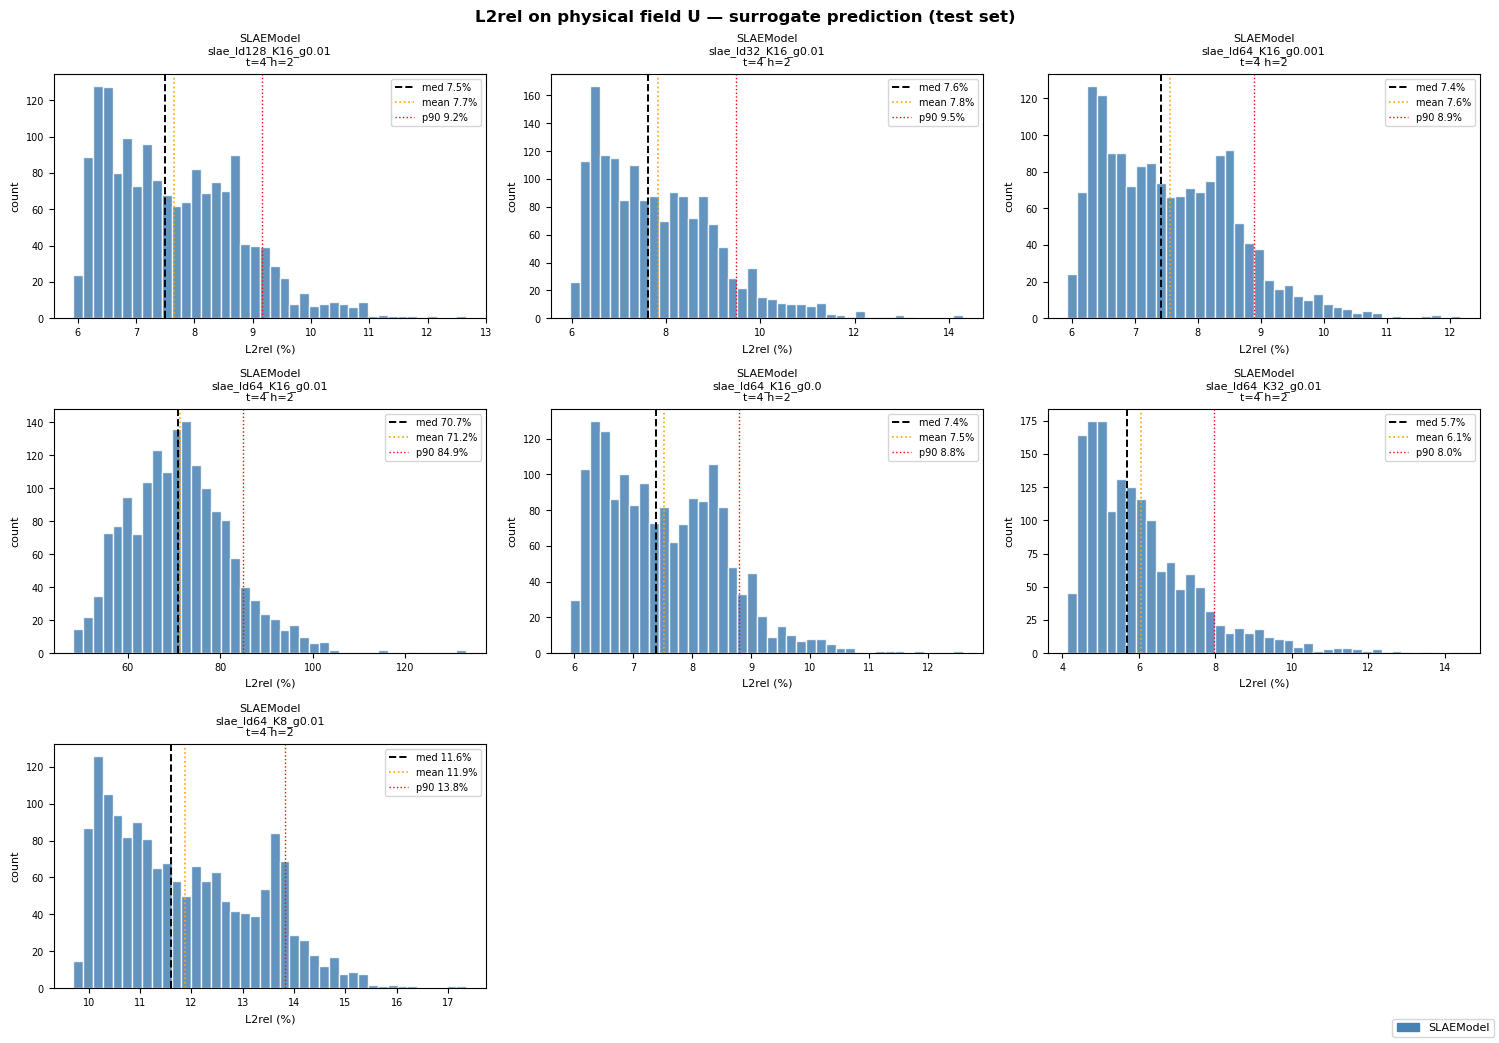

In [13]:
# Color palette by model family
PALETTE = {
    'SLAEModel'    : 'steelblue',
    'LLAEModel'    : 'tomato',
    'SLAESVDModel' : 'mediumseagreen',
    'LLAESVDModel' : 'orchid',
    'CorrectionAE' : 'darkorange',
}

_SURR_PAT = re.compile(
    r'^(?P<cls>[A-Za-z]+Model|CorrectionAE)__'
    r'(?P<ae_stem>.+?)__'
    r't(?P<n_trunk>\d+)h(?P<n_head>\d+)'
    r'(?P<suffix>.*)$'
)

def _pretty_name(name: str) -> str:
    m = _SURR_PAT.match(name)
    if m:
        cls  = m.group('cls')
        stem = m.group('ae_stem')
        nt   = m.group('n_trunk')
        nh   = m.group('n_head')
        return f'{cls}\n{stem}\nt={nt} h={nh}'
    return name


if results:
    names  = list(results.keys())
    n_ckpt = len(names)
    ncols  = min(3, n_ckpt)
    nrows  = (n_ckpt + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows))
    if n_ckpt == 1:
        axes = np.array([axes])
    axes = np.array(axes).flatten()

    for ax, name in zip(axes, names):
        l2     = results[name]
        mtype  = model_types.get(name, 'SLAEModel')
        color  = PALETTE.get(mtype, 'gray')
        median = np.median(l2)
        mean   = np.mean(l2)
        p90    = np.percentile(l2, 90)

        ax.hist(l2, bins=40, color=color, edgecolor='white', alpha=0.85)
        ax.axvline(median, color='black',  linestyle='--', linewidth=1.4, label=f'med {median:.1f}%')
        ax.axvline(mean,   color='orange', linestyle=':',  linewidth=1.2, label=f'mean {mean:.1f}%')
        ax.axvline(p90,    color='red',    linestyle=':',  linewidth=1.0, label=f'p90 {p90:.1f}%')
        ax.set_title(_pretty_name(name), fontsize=8)
        ax.set_xlabel('L2rel (%)', fontsize=8)
        ax.set_ylabel('count', fontsize=8)
        ax.legend(fontsize=7)
        ax.tick_params(labelsize=7)

    for ax in axes[n_ckpt:]:
        ax.set_visible(False)

    from matplotlib.patches import Patch
    legend_handles = [Patch(color=c, label=k) for k, c in PALETTE.items() if k in model_types.values()]
    fig.legend(handles=legend_handles, loc='lower right', fontsize=8, ncol=2)

    fig.suptitle('L2rel on physical field U — surrogate prediction (test set)', fontsize=12, fontweight='bold')
    fig.tight_layout()
    plt.show()
else:
    print('No surrogate checkpoints found in', CKPT_DIR)

## 5. Median comparison

In [ ]:
if results:
    medians = {n: float(np.median(v)) for n, v in results.items()}
    p25     = {n: float(np.percentile(v, 25)) for n, v in results.items()}
    p75     = {n: float(np.percentile(v, 75)) for n, v in results.items()}

    sorted_names = sorted(medians, key=lambda n: medians[n])
    bar_colors   = [PALETTE.get(model_types.get(n, ''), 'gray') for n in sorted_names]

    fig, ax = plt.subplots(figsize=(max(8, len(sorted_names) * 1.1), 5))
    x = np.arange(len(sorted_names))

    ax.bar(x, [medians[n] for n in sorted_names], color=bar_colors, alpha=0.85, zorder=2)

    yerr_low  = [medians[n] - p25[n] for n in sorted_names]
    yerr_high = [p75[n] - medians[n] for n in sorted_names]
    ax.errorbar(x, [medians[n] for n in sorted_names],
                yerr=[yerr_low, yerr_high],
                fmt='none', color='black', capsize=4, linewidth=1.5, zorder=3)

    ax.set_xticks(x)
    ax.set_xticklabels([_pretty_name(n) for n in sorted_names], rotation=40, ha='right', fontsize=8)
    ax.set_ylabel('Median L2rel (%)')
    ax.set_title('Surrogate checkpoint comparison (median ± IQR)', fontweight='bold')
    ax.grid(axis='y', alpha=0.4, zorder=0)

    from matplotlib.patches import Patch
    legend_handles = [Patch(color=c, label=k) for k, c in PALETTE.items() if k in model_types.values()]
    ax.legend(handles=legend_handles, fontsize=9)

    fig.tight_layout()
    plt.show()

## 6. Summary table

In [ ]:
if results:
    print(f"{'Checkpoint':<55}  {'type':<15}  {'median':>8}  {'mean':>8}  {'p90':>8}  {'n':>5}")
    print('-' * 106)
    for n in sorted(results, key=lambda n: np.median(results[n])):
        l2    = results[n]
        mtype = model_types.get(n, '?')
        print(f'{n:<55}  {mtype:<15}  {np.median(l2):>7.2f}%  {np.mean(l2):>7.2f}%  '
              f'{np.percentile(l2,90):>7.2f}%  {len(l2):>5}')

## 7. Family ablation plots

Violin plots showing the effect of each hyperparameter, grouping by model family.

In [ ]:
from collections import defaultdict
from matplotlib.lines import Line2D

# Parse surrogate checkpoint name into structured dict
def _parse_surr_name(name: str) -> dict | None:
    m = _SURR_PAT.match(name)
    if not m:
        return None
    ae_stem = m.group('ae_stem')
    cls     = m.group('cls')

    # Parse AE stem: slae_ld64_K16_g0.01  or  llae_ld128_K16_g0.01_ll  etc.
    ae_m = re.match(r'^(?P<ae>[a-z]+)_ld(?P<ld>\d+)_K(?P<K>\d+)_g(?P<g>[0-9.]+)(?P<ae_suf>.*)', ae_stem)
    if not ae_m:
        return None
    return {
        'name'   : name,
        'cls'    : cls,
        'ae'     : ae_m.group('ae'),
        'ld'     : int(ae_m.group('ld')),
        'K'      : int(ae_m.group('K')),
        'gamma'  : float(ae_m.group('g')),
        'n_trunk': int(m.group('n_trunk')),
        'n_head' : int(m.group('n_head')),
    }

parsed_rows = [r for r in (_parse_surr_name(n) for n in results) if r is not None]


def _violin_ablation(ax, rows, var_name, xlabel, title):
    if not rows:
        ax.set_title(f"{title}\n(no data)"); ax.axis('off'); return

    groups = defaultdict(list)
    for r in rows:
        groups[r[var_name]].extend(results[r['name']].tolist())

    xs_vals   = sorted(groups.keys())
    datasets  = [groups[v] for v in xs_vals]
    positions = list(range(len(xs_vals)))

    parts = ax.violinplot(datasets, positions=positions,
                          widths=0.65, showmedians=True, showmeans=True, showextrema=True)
    for pc in parts['bodies']:
        pc.set_alpha(0.55)
    parts['cmedians'].set_color('black');  parts['cmedians'].set_linewidth(2.2)
    parts['cmeans'].set_color('orange');   parts['cmeans'].set_linewidth(1.8)
    parts['cmeans'].set_linestyle('--')
    for key in ('cmaxes', 'cmins', 'cbars'):
        parts[key].set_linewidth(0.8)

    ax.set_xticks(positions)
    ax.set_xticklabels([str(v) for v in xs_vals], fontsize=9)
    ax.set_xlim(-0.7, len(xs_vals) - 0.3)
    ax.legend(handles=[
        Line2D([0], [0], color='black',  linewidth=2.2,              label='median'),
        Line2D([0], [0], color='orange', linewidth=1.8, linestyle='--', label='mean'),
    ], fontsize=8)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('L2rel (%)')
    ax.grid(alpha=0.3, axis='y')


# Group by model family (cls) and draw one figure per family
families = sorted(set(r['cls'] for r in parsed_rows))

for family in families:
    frows = [r for r in parsed_rows if r['cls'] == family]
    if not frows:
        continue

    # Ablations: K, latent_dim, n_trunk — skip if only 1 unique value
    ablations = []
    for var, xlabel, fixed_label in [
        ('K',      'K (num. Laplace freqs)', 'n_trunk'),
        ('ld',     'latent dim',             'K'),
        ('n_trunk','n_trunk',                'ld'),
    ]:
        if len(set(r[var] for r in frows)) > 1:
            ablations.append((var, xlabel))

    if not ablations:
        print(f'{family}: only one configuration found, skipping ablation plot.')
        continue

    fig, axes = plt.subplots(1, len(ablations), figsize=(6 * len(ablations), 5))
    if len(ablations) == 1:
        axes = [axes]

    for ax, (var, xlabel) in zip(axes, ablations):
        _violin_ablation(ax, frows, var, xlabel,
                         f'{family}: effect of {xlabel}')

    fig.suptitle(f'{family} — L2rel distributions (test set)', fontweight='bold')
    fig.tight_layout()
    plt.show()

## 8. Inference latency benchmark

In [ ]:
N_BENCH      = 200
N_WARMUP_LAT = 10
N_RUNS_LAT   = 50

# Pre-load theta for the benchmark samples (lightweight, no U needed for surrogate)
bench_theta = theta_np[test_idx[:N_BENCH]]   # (N_BENCH, 3)
print(f'Benchmark theta shape: {bench_theta.shape}')

bench = {}

def _time_gpu(fn, n_warmup, n_runs):
    for _ in range(n_warmup):
        fn()
    torch.cuda.synchronize()
    ev_s = torch.cuda.Event(enable_timing=True)
    ev_e = torch.cuda.Event(enable_timing=True)
    ms = []
    for _ in range(n_runs):
        ev_s.record(); fn(); ev_e.record()
        torch.cuda.synchronize()
        ms.append(ev_s.elapsed_time(ev_e))
    return np.array(ms)


for ckpt_path in tqdm(ckpt_paths, desc='latency benchmark'):
    name = os.path.splitext(os.path.basename(ckpt_path))[0]
    try:
        pipe  = InferencePipeline.from_checkpoint(ckpt_path, device=device)
        theta_dev = torch.tensor(bench_theta[:1], dtype=torch.float32, device=device)
        theta_mean = torch.tensor(pipe.ckpt['theta_mean'], dtype=torch.float32, device=device)
        theta_std  = torch.tensor(pipe.ckpt['theta_std'],  dtype=torch.float32, device=device)
        theta_norm = (theta_dev - theta_mean) / theta_std

        if device == 'cuda':
            def lat_fn():
                with torch.no_grad():
                    pipe.model.generate(theta_norm)
            lat_ms = _time_gpu(lat_fn, N_WARMUP_LAT, N_RUNS_LAT)
            bench[name] = dict(lat_med=np.median(lat_ms), lat_std=np.std(lat_ms))
        else:
            import time
            times = []
            for _ in range(N_RUNS_LAT + N_WARMUP_LAT):
                t0 = time.perf_counter()
                with torch.no_grad():
                    pipe.model.generate(theta_norm)
                times.append((time.perf_counter() - t0) * 1e3)
            times = np.array(times[N_WARMUP_LAT:])
            bench[name] = dict(lat_med=np.median(times), lat_std=np.std(times))

        mtype = pipe.model_type
        print(f'{name:<55}  lat={bench[name]["lat_med"]:6.1f}±{bench[name]["lat_std"]:.1f} ms  [{mtype}]')

        pipe.model.cpu(); del pipe
        if device == 'cuda': torch.cuda.empty_cache()
        gc.collect()

    except Exception as e:
        print(f'{name}  ERROR: {e}')

print('\nDone.')

In [ ]:
if bench and results:
    # Only plot checkpoints that have both latency and L2rel
    common = [n for n in bench if n in results]
    common_sorted = sorted(common, key=lambda n: bench[n]['lat_med'])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    x = np.arange(len(common_sorted))
    col = [PALETTE.get(model_types.get(n, ''), 'gray') for n in common_sorted]

    # Latency
    lats = [bench[n]['lat_med'] for n in common_sorted]
    stds = [bench[n]['lat_std']  for n in common_sorted]
    ax1.bar(x, lats, color=col, alpha=0.85, zorder=2)
    ax1.errorbar(x, lats, yerr=stds, fmt='none', color='black', capsize=4, linewidth=1.5, zorder=3)
    ax1.set_xticks(x)
    ax1.set_xticklabels([_pretty_name(n) for n in common_sorted], rotation=40, ha='right', fontsize=7)
    ax1.set_ylabel('Latency (ms / sample)')
    ax1.set_title('Latency (bs=1)', fontweight='bold')
    ax1.grid(axis='y', alpha=0.4, zorder=0)

    # Accuracy vs latency scatter
    for n in common:
        ax2.scatter(bench[n]['lat_med'], np.median(results[n]),
                    color=PALETTE.get(model_types.get(n, ''), 'gray'),
                    s=80, zorder=3, label=model_types.get(n, ''))
        ax2.annotate(n.split('__')[0], (bench[n]['lat_med'], np.median(results[n])),
                     fontsize=6, textcoords='offset points', xytext=(4, 2))

    ax2.set_xlabel('Latency (ms)')
    ax2.set_ylabel('Median L2rel (%)')
    ax2.set_title('Accuracy vs Latency', fontweight='bold')
    ax2.grid(alpha=0.3)

    from matplotlib.patches import Patch
    legend_handles = [Patch(color=c, label=k) for k, c in PALETTE.items() if k in model_types.values()]
    for ax in (ax1, ax2):
        ax.legend(handles=legend_handles, fontsize=8)

    gpu_name = torch.cuda.get_device_name(0) if device == 'cuda' else 'CPU'
    fig.suptitle(f'Surrogate inference benchmark — {gpu_name}', fontweight='bold')
    fig.tight_layout()
    plt.show()